# From proteins to precursors: a first tour of `alphapepttools` + `mulink`

This notebook is a gentle, end-to-end walkthrough for people who have **never used
either package**. We start from a raw DIA-NN report and finish with two volcano
plots: one at the **protein** level, and one at the **precursor** level in which we
highlight the precursors belonging to a single protein of interest.

**The two tools, in one sentence each**

| Package | What it does |
| --- | --- |
| [`alphapepttools`](https://github.com/MannLabs/alphapepttools) | Reads search-engine output into `AnnData` and gives you QC, preprocessing, statistics and plots that follow proteomics best practice. |
| [`mulink`](https://github.com/lucas-diedrich/mulink) | Remembers *how features at different levels relate to each other* (precursor → protein → gene) inside a `MuData` object, so you can move between levels without bookkeeping. |

**The dataset.** 20 samples from a Deep Visual Proteomics experiment, acquisition
approach `cnDVP`, measured on a timsTOF and searched with DIA-NN. Each sample is a
laser-excised region of a tissue section, taken from one of two compartments:

* `Cancer` — tumour regions (9 samples)
* `Immune` — immune-cell-rich regions (11 samples)

…across two donors (`sample_id` 991 and 992). Our biological question is deliberately
simple: **which proteins distinguish immune regions from tumour regions?**

**The plan**

1. Read one DIA-NN report at three feature levels
2. Attach the sample metadata
3. Preprocess (normalise → log → filter)
4. Check group separation with PCA
5. Protein-level differential expression → volcano
6. Link the levels with `mulink`
7. Ask *"which precursors make up this protein?"* → precursor-level volcano

## Setup on Google Colab

Running this notebook in Colab? The cell below clones the repository and installs
the pinned dependencies with [uv](https://docs.astral.sh/uv/). It is a no-op when
you run the notebook locally, so you can leave it in place either way.

In [1]:
# Colab bootstrap -- clones the repo and installs dependencies with uv.
# Does nothing when the notebook runs outside Colab.
import glob
import os
import sys

IN_COLAB = "google.colab" in sys.modules

REPO_URL = "https://github.com/josenimo/HUPO_scverse_demo.git"
REPO_DIR = "HUPO_scverse_demo"

if IN_COLAB:
    # 1. Clone & change directory
    if not os.path.exists(REPO_DIR):
        !git clone --depth 1 {REPO_URL}
    %cd {REPO_DIR}

    # 2. Install the uv binary
    !curl -LsSf https://astral.sh/uv/install.sh | sh
    os.environ["PATH"] = f"/root/.local/bin:{os.environ['PATH']}"

    # 3. Sync into a local .venv, pinned to the interpreter this runtime is using.
    #    Without --python, uv prefers its own managed Python and may build the venv
    #    on a different minor version -- whose compiled wheels (numpy, pandas, ...)
    #    then fail to import back into this kernel.
    !uv sync --no-install-project --python {sys.executable}

    # 4. Point the active runtime at the .venv site-packages
    site_packages = glob.glob(f"{os.getcwd()}/.venv/lib/python*/site-packages")
    if not site_packages:
        raise RuntimeError("uv sync did not create a .venv -- check the output above")
    if site_packages[0] not in sys.path:
        sys.path.insert(0, site_packages[0])

    print(f"\n\u2713 added {site_packages[0]} to sys.path")
    print("\u2713 environment ready to import")

    missing = [
        path
        for path in ("data/report_cnDVP.parquet", "data/metadata_cnDVP.csv")
        if not os.path.exists(path)
    ]
    if missing:
        print("\n! missing data files:", ", ".join(missing))
else:
    print("not running on Colab -- using the current environment")

not running on Colab -- using the current environment


## 0. Setup

In [2]:
from pathlib import Path

import matplotlib.patches as mpatches
import pandas as pd

import alphapepttools as at
import mulink  # noqa: F401  -- importing registers the `.link` namespace on MuData

# Run from either the repo root or the notebooks/ folder
DATA = Path("data") if Path("data").exists() else Path("../data")
REPORT = DATA / "report_cnDVP.parquet"
METADATA = DATA / "metadata_cnDVP.csv"

# Everything downstream keys off these three choices -- change them and re-run
CONDITION = "tissue"                     # column in the metadata to compare
COMPARISON = ("Cancer", "Immune")        # (group 1, group 2) for the t-test
PROTEIN_OF_INTEREST = "P08575"           # PTPRC / CD45, the pan-leukocyte marker

print(f"alphapepttools {at.__version__}  |  mulink {mulink.__version__}")

c:\Users\kmadden\AppData\Local\miniforge3\envs\hupo-scverse-demo\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


alphapepttools 0.4.0  |  mulink 0.0.4-dev0


## 1. Read the DIA-NN report

A DIA-NN `report.parquet` is a **long table**: one row per precursor per run. Most
analyses want a **matrix** instead (samples × features), and which matrix you want
depends on the question. `at.io.read_psm_table` builds that matrix and returns an
[`AnnData`](https://anndata.readthedocs.io) object:

* `adata.X` — the intensity matrix, **samples as rows, features as columns**
* `adata.obs` — one row of metadata per sample
* `adata.var` — one row of metadata per feature

Here we use `alphapepttools` to read the **protein groups** from the DIA-NN report.

In [3]:
adata_proteins = at.io.read_psm_table(
    REPORT,
    search_engine="diann",
    level="proteins",
    var_columns=["proteins", "genes"],  # keep gene names so we can label plots with them
)

adata_proteins

AnnData object with n_obs × n_vars = 20 × 5120
    var: 'genes'
    layers: None (.X)

In [4]:
adata_proteins.obs

""
raw_name
Bluto_20251020_JoN_P37E24_991_Cancer_cnDVP_1_S3-A7_1_14821
Bluto_20251020_JoN_P37E35_991_Cancer_cnDVP_5_S3-B6_1_14823
Bluto_20251020_JoN_P37E45_991_Cancer_cnDVP_3_S3-C6_1_14825
Bluto_20251020_JoN_P37E56_991_Cancer_cnDVP_4_S3-D9_1_14827
Bluto_20251024_JoN_P37E01_992_Cancer_cnDVP_02_S6-H10_1_14849
Bluto_20251027_JoN_P37E01_991_Immune_cnDVP_02_S4-D7_1_14957
Bluto_20251027_JoN_P37E01_991_Immune_cnDVP_03_S4-C2_1_14961
Bluto_20251027_JoN_P37E01_991_Immune_cnDVP_04_S4-E9_1_14965
Bluto_20251027_JoN_P37E01_991_Immune_cnDVP_05_S4-G6_1_14969


In [5]:
adata_proteins.var

,genes
proteins,
A0A024R1R8;Q9Y2S6,TMA7;TMA7B
A0A075B6H7,IGKV3-7
A0A075B6I0,IGLV8-61
A0A075B6J9,IGLV2-18
A0A075B6K5;P80748,IGLV3-21;IGLV3-9
...,...
Q9Y6W3,CAPN7
Q9Y6W5,WASF2
Q9Y6X3,MAU2


In [6]:
adata_proteins.X

array([[         nan,  23530.914  ,   2647.297  , ...,    962.30054,
          2559.499  ,   5221.3203 ],
       [  2557.881  ,  14982.33   ,   2145.9397 , ...,   1207.9064 ,
          2749.2017 ,   4441.652  ],
       [         nan, 100511.53   ,   4897.212  , ...,          nan,
          2553.6787 ,   5131.961  ],
       ...,
       [         nan,  96063.63   ,   7504.163  , ...,          nan,
                 nan,   6725.7505 ],
       [         nan,  30703.361  ,          nan, ...,    850.44507,
          2362.039  ,   6067.194  ],
       [  3208.9956 , 247604.78   ,  11815.997  , ...,   1754.548  ,
                 nan,   6372.3677 ]], shape=(20, 5120), dtype=float32)

## 2. Attach the sample metadata

`at.pp.add_metadata` joins a `DataFrame` onto `.obs` (`axis=0`) or `.var` (`axis=1`).
It matches on the **index**, not on row order, so it cannot silently mislabel your
samples — but it does mean the index has to match.

Our metadata identifies samples by raw file name (`..._14821.d`), while DIA-NN's
`Run` column — which became `adata.obs_names` — has no `.d` suffix. One
`removesuffix` and they line up.

In [7]:
# sample_id is a donor label, not a quantity -- read it as text so it is never
# treated as a number in plots or tests
metadata = pd.read_csv(METADATA, dtype={"sample_id": str})
metadata.index = metadata["File Name"].str.removesuffix(".d")  # match DIA-NN's `Run`

metadata.head()

,File Name,sample_id,tissue,approach,replicate_n,evowell,lcms_id,Precursors.Identified,Proteins.Identified
File Name,,,,,,,,,
Bluto_20251020_JoN_P37E24_991_Cancer_cnDVP_1_S3-A7_1_14821,Bluto_20251020_JoN_P37E24_991_Cancer_cnDVP_1_S...,991,Cancer,cnDVP,1,S3-A7,14821,25381,4213
Bluto_20251020_JoN_P37E35_991_Cancer_cnDVP_5_S3-B6_1_14823,Bluto_20251020_JoN_P37E35_991_Cancer_cnDVP_5_S...,991,Cancer,cnDVP,5,S3-B6,14823,22837,3744
Bluto_20251020_JoN_P37E45_991_Cancer_cnDVP_3_S3-C6_1_14825,Bluto_20251020_JoN_P37E45_991_Cancer_cnDVP_3_S...,991,Cancer,cnDVP,3,S3-C6,14825,24651,4049
Bluto_20251020_JoN_P37E56_991_Cancer_cnDVP_4_S3-D9_1_14827,Bluto_20251020_JoN_P37E56_991_Cancer_cnDVP_4_S...,991,Cancer,cnDVP,4,S3-D9,14827,23421,3819
Bluto_20251024_JoN_P37E01_992_Cancer_cnDVP_02_S6-H10_1_14849,Bluto_20251024_JoN_P37E01_992_Cancer_cnDVP_02_...,992,Cancer,cnDVP,2,S6-H10,14849,32643,4880


In [8]:
adata_proteins = at.pp.add_metadata(adata_proteins, metadata, axis=0)
adata_proteins.obs.head()

,File Name,sample_id,tissue,approach,replicate_n,evowell,lcms_id,Precursors.Identified,Proteins.Identified
raw_name,,,,,,,,,
Bluto_20251020_JoN_P37E24_991_Cancer_cnDVP_1_S3-A7_1_14821,Bluto_20251020_JoN_P37E24_991_Cancer_cnDVP_1_S...,991,Cancer,cnDVP,1,S3-A7,14821,25381,4213
Bluto_20251020_JoN_P37E35_991_Cancer_cnDVP_5_S3-B6_1_14823,Bluto_20251020_JoN_P37E35_991_Cancer_cnDVP_5_S...,991,Cancer,cnDVP,5,S3-B6,14823,22837,3744
Bluto_20251020_JoN_P37E45_991_Cancer_cnDVP_3_S3-C6_1_14825,Bluto_20251020_JoN_P37E45_991_Cancer_cnDVP_3_S...,991,Cancer,cnDVP,3,S3-C6,14825,24651,4049
Bluto_20251020_JoN_P37E56_991_Cancer_cnDVP_4_S3-D9_1_14827,Bluto_20251020_JoN_P37E56_991_Cancer_cnDVP_4_S...,991,Cancer,cnDVP,4,S3-D9,14827,23421,3819
Bluto_20251024_JoN_P37E01_992_Cancer_cnDVP_02_S6-H10_1_14849,Bluto_20251024_JoN_P37E01_992_Cancer_cnDVP_02_...,992,Cancer,cnDVP,2,S6-H10,14849,32643,4880


In [9]:
adata_proteins

AnnData object with n_obs × n_vars = 20 × 5120
    obs: 'File Name', 'sample_id', 'tissue', 'approach', 'replicate_n', 'evowell', 'lcms_id', 'Precursors.Identified', 'Proteins.Identified'
    var: 'genes'
    layers: None (.X)

In [10]:
# The design we are about to test: 2 compartments x 2 donors
adata_proteins.obs.groupby([CONDITION, "sample_id"], observed=True).size()

tissue  sample_id
Cancer  991          4
        992          5
Immune  991          5
        992          6
dtype: int64

### Subsetting an AnnData object

An `AnnData` object is sliced like a matrix: `adata[obs_to_keep, var_to_keep]`.

Below, `:` keeps **all samples**, and the list keeps only the three proteins we name.

In [11]:
adata_proteins[:, ["Q9Y6W3", "Q9Y6W5", "Q9Y6X3"]]

View of AnnData object with n_obs × n_vars = 20 × 3
    obs: 'File Name', 'sample_id', 'tissue', 'approach', 'replicate_n', 'evowell', 'lcms_id', 'Precursors.Identified', 'Proteins.Identified'
    var: 'genes'
    layers: None (.X)

In [12]:
adata_proteins[:, ["Q9Y6W3", "Q9Y6W5", "Q9Y6X3"]].var

,genes
proteins,
Q9Y6W3,CAPN7
Q9Y6W5,WASF2
Q9Y6X3,MAU2


In [13]:
adata_proteins[:, ["Q9Y6W3", "Q9Y6W5", "Q9Y6X3"]].X

ArrayView([[ 2278.5571 , 14760.568  ,   962.30054],
           [ 2528.6313 , 17712.66   ,  1207.9064 ],
           [ 1476.09   , 15659.751  ,         nan],
           [ 1551.8098 , 15241.254  ,  1451.3182 ],
           [ 2188.8306 , 15111.7    ,   756.1338 ],
           [ 3969.5256 , 25019.852  ,         nan],
           [ 2860.0916 , 24973.91   ,  1316.0833 ],
           [ 3468.2966 , 24496.186  ,  1629.711  ],
           [ 3678.1917 , 20665.12   ,   831.43756],
           [ 4993.018  , 17292.238  ,         nan],
           [        nan, 14077.754  ,  1626.0271 ],
           [ 1848.6764 , 15796.138  ,   624.1478 ],
           [ 2073.886  , 20608.713  ,  1062.7046 ],
           [ 2313.2305 , 14915.223  ,   846.2612 ],
           [ 3299.3098 , 28118.648  ,         nan],
           [ 4860.994  , 23762.34   ,         nan],
           [ 5992.1426 , 30831.3    ,         nan],
           [ 4822.6714 , 26235.504  ,         nan],
           [ 4005.6838 , 25032.6    ,   850.44507],
           [

## 3. A first look at the data

`alphapepttools` plots all take a matplotlib `ax`, so you can mix them freely with
your own matplotlib or seaborn code. `at.pl.create_figure` returns a figure plus an
axis manager; call `.next()` to walk through the panels.

> **Worth knowing:** `axm[row, col]` also *rewinds* the `.next()` counter to that
> panel, so interleaving the two styles can quietly draw two plots into the same
> panel and leave the next one empty. The habit that avoids this entirely: grab the
> panels you need into named variables up front, then forget about `axm`.

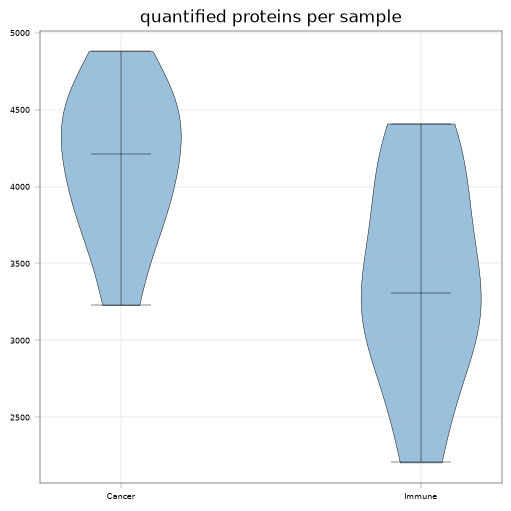

In [14]:
fig, axm = at.pl.create_figure(1, 1, figsize=(5, 5))
ax_depth = axm.next()

# How deep is each sample? (DIA-NN's own protein count, straight from .obs)
at.pl.violinplot(
    ax=ax_depth,
    data=adata_proteins,
    grouping_column=CONDITION,
    value_column="Proteins.Identified",
)
ax_depth.set_title("quantified proteins per sample");

Tumour regions are quantified more deeply than immune regions — a real difference in
how much material each excised shape contained, and a good reminder that we must
normalise before comparing.

## 4. Preprocess: normalise → log → filter

Three steps, in this order:

1. **`at.pp.normalize`** — put samples on a common scale. `total_median` rescales each
   sample so that its total intensity matches the median total intensity across all
   samples, correcting the loading differences we just saw. This is a *multiplicative*
   correction, so it is applied to the raw (linear) intensities.
2. **`at.pp.nanlog`** — log2-transform. Proteomics intensities span orders of
   magnitude and are roughly log-normal; t-tests want something symmetric. "nan" in
   the name is the polite part: zeros become `NaN` ("not detected") instead of `-inf`.
3. **`at.pp.filter_data_completeness`** — drop features too sparse to test. With
   `group_column="tissue"` and `keep_strategy="any"`, a protein is kept if it is
   well-measured in **at least one** group. That choice matters: a protein present in
   every immune region and absent from every tumour region is a *result*, not noise,
   and a naive global filter would throw it away.

Note the **layer checkpointing** pattern: each result is saved in
`adata.layers[...]`, and each step starts from the layer saved by the previous one. You
can always go back to the data as they were two steps ago, and re-running a cell never
applies a step twice.

In [15]:
adata_proteins[:5, :5].X

ArrayView([[        nan,  23530.914 ,   2647.297 ,         nan,
              4822.7603],
           [  2557.881 ,  14982.33  ,   2145.9397,   1456.0916,
              2445.0227],
           [        nan, 100511.53  ,   4897.212 ,         nan,
             20051.338 ],
           [  5011.446 ,  26928.463 ,         nan,         nan,
              5419.301 ],
           [  5312.418 ,  26062.023 ,   2356.729 ,         nan,
              9116.484 ]], dtype=float32)

In [16]:
adata_proteins = adata_proteins.copy()
if "raw" not in adata_proteins.layers:  # store the untouched intensities only once
    adata_proteins.layers["raw"] = adata_proteins.X.copy()

adata_proteins[:5, :5].layers["raw"]

ArrayView([[        nan,  23530.914 ,   2647.297 ,         nan,
              4822.7603],
           [  2557.881 ,  14982.33  ,   2145.9397,   1456.0916,
              2445.0227],
           [        nan, 100511.53  ,   4897.212 ,         nan,
             20051.338 ],
           [  5011.446 ,  26928.463 ,         nan,         nan,
              5419.301 ],
           [  5312.418 ,  26062.023 ,   2356.729 ,         nan,
              9116.484 ]], dtype=float32)

In [17]:
adata_proteins.X = adata_proteins.layers["raw"].copy()  # start from the raw intensities
at.pp.normalize(adata_proteins, strategy="total_median")
adata_proteins.layers["normalized"] = adata_proteins.X.copy()

adata_proteins[:5, :5].layers["normalized"]

ArrayView([[        nan,  27804.938 ,   3128.1375,         nan,
              5698.7397],
           [  3094.2114,  18123.79  ,   2595.895 ,   1761.4012,
              2957.6892],
           [        nan, 119541.09  ,   5824.3867,         nan,
             23847.6   ],
           [  5853.682 ,  31454.129 ,         nan,         nan,
              6330.0825],
           [  6959.1216,  34140.535 ,   3087.2502,         nan,
             11942.344 ]], dtype=float32)

In [18]:
adata_proteins.X = adata_proteins.layers["normalized"].copy()  # start from the normalised intensities
at.pp.nanlog(adata_proteins, base=2, verbosity=0)
adata_proteins.layers["log2"] = adata_proteins.X.copy()

adata_proteins[:5, :5].layers["log2"]

ArrayView([[      nan, 14.763054, 11.611088,       nan, 12.476427],
           [11.595356, 14.145597, 11.342016, 10.782508, 11.530254],
           [      nan, 16.867147, 12.507891,       nan, 14.541556],
           [12.515129, 14.940962,       nan,       nan, 12.628009],
           [12.764689, 15.059198, 11.592107,       nan, 13.543798]],
          dtype=float32)

In [19]:
adata_proteins.var

,genes
proteins,
A0A024R1R8;Q9Y2S6,TMA7;TMA7B
A0A075B6H7,IGKV3-7
A0A075B6I0,IGLV8-61
A0A075B6J9,IGLV2-18
A0A075B6K5;P80748,IGLV3-21;IGLV3-9
...,...
Q9Y6W3,CAPN7
Q9Y6W5,WASF2
Q9Y6X3,MAU2


In [20]:
at.pp.filter_data_completeness(
    adata_proteins,
    max_missing_fraction=0.7,  # flag features missing in more than 70% of samples
    group_column=CONDITION,
    keep_strategy="any",       # keep a feature if it is complete in EITHER group
    action="flag",             # only mark features -- we subset in the next cell
)

INFO:root:pp.filter_data_completeness(): flag 123 / 5120 features with >0.70 missing fraction.


AnnData object with n_obs × n_vars = 20 × 5120
    obs: 'File Name', 'sample_id', 'tissue', 'approach', 'replicate_n', 'evowell', 'lcms_id', 'Precursors.Identified', 'Proteins.Identified'
    var: 'genes', 'passed_threshold_missing_values'
    layers: None (.X), 'raw', 'normalized', 'log2'

In [21]:
adata_proteins.var

,genes,passed_threshold_missing_values
proteins,,
A0A024R1R8;Q9Y2S6,TMA7;TMA7B,True
A0A075B6H7,IGKV3-7,True
A0A075B6I0,IGLV8-61,True
A0A075B6J9,IGLV2-18,True
A0A075B6K5;P80748,IGLV3-21;IGLV3-9,True
...,...,...
Q9Y6W3,CAPN7,True
Q9Y6W5,WASF2,True
Q9Y6X3,MAU2,True


In [22]:
keep = adata_proteins.var["passed_threshold_missing_values"]
adata_filt_70pct = adata_proteins[:, keep].copy()

In [23]:
print(f"proteins   {adata_proteins.shape[1]:>6} -> {adata_filt_70pct.shape[1]:>6} features")

proteins     5120 ->   4997 features


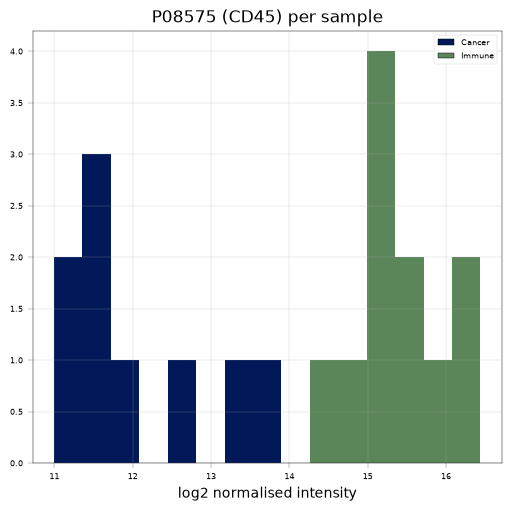

In [24]:
# Our protein of interest, CD45 -- already clearly bimodal between compartments
fig, axm = at.pl.create_figure(1, 1, figsize=(5, 5))
ax_marker = axm.next()

at.pl.histogram(
    ax=ax_marker,
    data=adata_proteins,
    value_column=PROTEIN_OF_INTEREST,
    color_map_column=CONDITION,
    bins=15,
    legend="auto",
)
ax_marker.set_xlabel("log2 normalised intensity")
ax_marker.set_title(f"{PROTEIN_OF_INTEREST} (CD45) per sample");

## 5. Do the groups separate at all? (PCA)

Before testing thousands of proteins one at a time, check whether the effect you are
looking for is visible in the data as a whole. If PC1 already separates your groups,
differential expression will be easy. If instead PC1 separates *donors* or *batches*,
you have a confounder to deal with first.

PCA needs a complete matrix, so we fill the remaining gaps.
`at.pp.impute_gaussian` draws from a low, narrow Gaussian — the Perseus-style
"missing means low abundance" assumption. We impute into a **copy** used only for the
PCA; the statistics later run on the un-imputed data, where a missing value stays
missing.

`alphapepttools` stores the result in `.obsm["X_pca_obs"]` rather than scanpy's
`X_pca`: the `_obs` suffix makes it explicit that *samples* are the points.

In [25]:
# Store the grouping columns as categories so plots treat them as groups
for column in [CONDITION, "sample_id"]:
    adata_filt_70pct.obs[column] = adata_filt_70pct.obs[column].astype("category")

In [26]:
proteins_pca = at.pp.impute_gaussian(adata_filt_70pct, copy=True)
at.tl.pca(proteins_pca, n_comps=5)

proteins_pca

INFO:alphapepttools.tl.embeddings:computing PCA


AnnData object with n_obs × n_vars = 20 × 4997
    obs: 'File Name', 'sample_id', 'tissue', 'approach', 'replicate_n', 'evowell', 'lcms_id', 'Precursors.Identified', 'Proteins.Identified'
    var: 'genes', 'passed_threshold_missing_values'
    uns: 'variance_pca_obs'
    obsm: 'X_pca_obs'
    varm: 'PCs_pca_obs'
    layers: None (.X), 'raw', 'normalized', 'log2'

c:\Users\kmadden\AppData\Local\miniforge3\envs\hupo-scverse-demo\Lib\functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


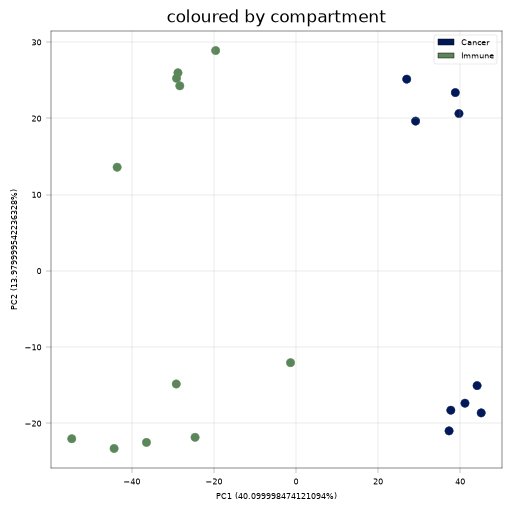

In [27]:
fig, axm = at.pl.create_figure(1, 1, figsize=(5, 5))
ax_tissue = axm.next()

at.pl.plot_pca(data=proteins_pca, ax=ax_tissue, color_map_column=CONDITION, legend="auto")
ax_tissue.set_title("coloured by compartment");

## 6. Protein-level differential expression

`at.tl.diff_exp_ttest` runs a Welch t-test per feature and returns a tidy
`DataFrame` — no reshaping needed. It already includes Benjamini-Hochberg corrected
p-values (`fdr`) and the `-log10(...)` columns the volcano plot expects.

`min_valid_values` is the guard rail: a feature must have at least that many
*measured* samples **in each group** to be tested at all. Features that fall short
come back with `NaN` statistics rather than a fabricated p-value — remember this,
because it comes back to bite us in step 10.

In [28]:
de_proteins = at.tl.diff_exp_ttest(
    adata_filt_70pct,
    between_column=CONDITION,
    comparison=COMPARISON,  # log2fc > 0 means higher in Cancer
    min_valid_values=3,
)

# Carry the gene symbols over from .var so the plot can be labelled with names
de_proteins["genes"] = adata_filt_70pct.var["genes"].reindex(de_proteins.index)

de_proteins.head()

Comparing groups: Cancer vs Immune


,condition_pair,protein,log2fc,p_value,-log10(p_value),fdr,-log10(fdr),method,max_level_1_samples,max_level_2_samples,genes
A0A024R1R8;Q9Y2S6,Cancer_VS_Immune,A0A024R1R8;Q9Y2S6,-0.423543,0.467009,0.330675,0.541995,0.266005,ttest,9,11,TMA7;TMA7B
A0A075B6H7,Cancer_VS_Immune,A0A075B6H7,-1.457898,0.001222,2.912853,0.004503,2.346477,ttest,9,11,IGKV3-7
A0A075B6I0,Cancer_VS_Immune,A0A075B6I0,-1.195721,0.001721,2.764254,0.005944,2.225903,ttest,9,11,IGLV8-61
A0A075B6J9,Cancer_VS_Immune,A0A075B6J9,-1.043561,NaN,NaN,NaN,NaN,ttest,9,11,IGLV2-18
A0A075B6K5;P80748,Cancer_VS_Immune,A0A075B6K5;P80748,-1.528709,0.006347,2.197465,0.016189,1.790790,ttest,9,11,IGLV3-21;IGLV3-9


## 7. The protein volcano

`at.pl.volcano` works with **layers**: a list of `(column, value(s), colour_key)`
tuples. Each point is assigned to the *first* layer it matches, so the list acts as a
painting order — later entries end up in the background. Anything matching nothing
lands in a grey default layer.

`label_layers` says which of those layers get text labels, and `x_label_anchors`
stacks the labels tidily at fixed x-positions instead of letting them collide on top
of the points.

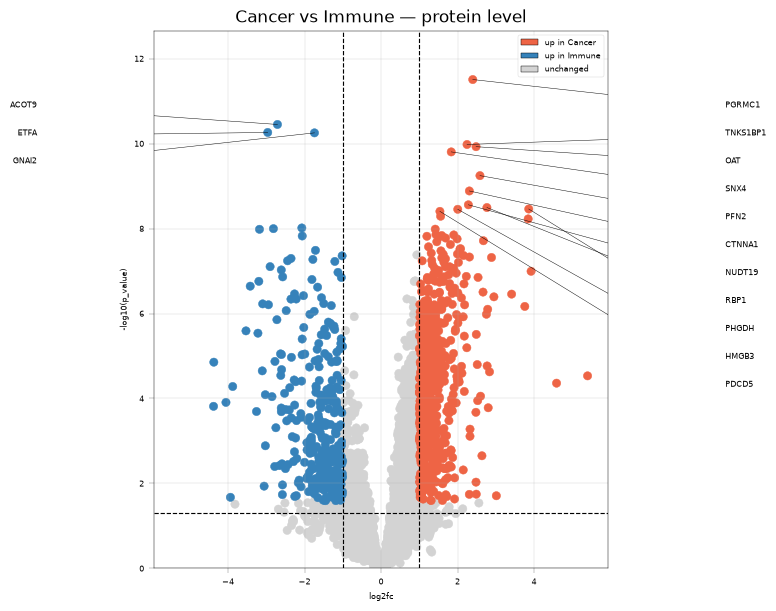

In [29]:
colors = {
    "up in Cancer": at.pl.BaseColors.get("orange"),
    "up in Immune": at.pl.BaseColors.get("blue"),
    "unchanged": at.pl.BaseColors.get("grey"),
}

# Label each protein by its significance status
FDR_CUTOFF, FC_CUTOFF = 0.05, 1.0
de_proteins["status"] = "unchanged"
de_proteins.loc[
    (de_proteins["fdr"] < FDR_CUTOFF) & (de_proteins["log2fc"] > FC_CUTOFF), "status"
] = "up in Cancer"
de_proteins.loc[
    (de_proteins["fdr"] < FDR_CUTOFF) & (de_proteins["log2fc"] < -FC_CUTOFF), "status"
] = "up in Immune"

fig, axm = at.pl.create_figure(1, 1, figsize=(7.5, 6))
ax = axm.next()

at.pl.volcano(
    data=de_proteins,
    x_column="log2fc",
    y_column="-log10(p_value)",
    ax=ax,
    layers=[
        ("status", "up in Cancer", "up in Cancer"),
        ("status", "up in Immune", "up in Immune"),
        ("status", "unchanged", "unchanged"),
    ],
    color_dict=colors,
    label_layers=["up in Cancer", "up in Immune"],
    display_id_column="genes",  # label with gene symbols, not UniProt IDs
    max_labels=14,
    x_label_anchors=[-9, 9],
    x_thresholds=(-FC_CUTOFF, FC_CUTOFF),
    legend="auto",
)
ax.set_title(f"{COMPARISON[0]} vs {COMPARISON[1]} — protein level");

The result is lopsided — over a thousand proteins up in the immune regions against a
handful up in the tumour regions — which is what you expect when one compartment is
packed with a cell type the other lacks.

The labelled hits read like a textbook: **PTPRC** (CD45), **BTK**, **DOK2**,
**ICAM3**, **GIMAP4/5**, **APOBEC3G**, **F13A1** — canonical leukocyte proteins. The
laser captured what we asked it to capture, which is the best sanity check a spatial
proteomics experiment can give you.

So far, so ordinary. Now the part that needs `mulink`.

## 8. Linking the levels with `mulink`

A protein-level hit is an **aggregate**: DIA-NN measured several precursors and
summarised them into one number per protein. To look at the evidence behind a hit, we
need to know which precursors belong to which protein.

We read two more **feature levels** from the same report — precursors and genes — and
let `at.io.mulink_from_anndatas` combine all three into one `MuData` object that
remembers how the levels are linked. The `var_columns` argument is the important bit:
it stores each precursor's protein and gene in `.var`, which is what `mulink` uses to
build the links.

> **Note for DIA-NN users:** a DIA-NN report has no peptide-level intensities, so the
> hierarchy here is **precursors → proteins → genes**. A precursor is a peptide in a
> particular charge state and modification.

In [30]:
# Read in two additional feature levels: precursors and genes
adata_precursors = at.io.read_psm_table(
    REPORT,
    search_engine="diann",
    level="precursors",
    var_columns=["proteins", "genes"],  # <- lets mulink link precursors up to proteins
)

adata_genes = at.io.read_psm_table(
    REPORT,
    search_engine="diann",
    level="genes",
)

for name, adata in [
    ("precursors", adata_precursors),
    ("proteins", adata_proteins),
    ("genes", adata_genes),
]:
    print(f"{name:11s} {adata.shape[0]:>3} samples x {adata.shape[1]:>6} features")

precursors   20 samples x  36068 features
proteins     20 samples x   5120 features
genes        20 samples x   5096 features


In [31]:
# .var remembers which protein and gene each precursor belongs to
adata_precursors.var.head()

,proteins,genes
precursor_id,,
(UniMod:1)AAAAAAAAAAGAAGGR2,Q86U42,PABPN1
(UniMod:1)AAAAAAGAASGLPGPVAQGLK2,Q96P70,IPO9
(UniMod:1)AAAAAAGAASGLPGPVAQGLK3,Q96P70,IPO9
(UniMod:1)AAAAAAGAGPEM(UniMod:35)VR2,P28482,MAPK1
(UniMod:1)AAAAAAGEAR2,P09417,QDPR


In [32]:
mdata = at.io.mulink_from_anndatas(
    {
        "precursors": adata_precursors,
        "proteins": adata_proteins,
        "genes": adata_genes,
    }
)

mdata

100%|██████████| 2/2 [00:00<00:00,  4.80it/s]


MuData object with n_obs × n_vars = 20 × 46284
  varp:	'feature_mapping'
  3 modalities
    precursors:	20 × 36068
      var:	'proteins', 'genes'
      layers:	None
    proteins:	20 × 5120
      obs:	'File Name', 'sample_id', 'tissue', 'approach', 'replicate_n', 'evowell', 'lcms_id', 'Precursors.Identified', 'Proteins.Identified'
      var:	'genes', 'passed_threshold_missing_values'
      layers:	None, 'raw', 'normalized', 'log2'
    genes:	20 × 5096
      layers:	None

In [33]:
# All links between levels live in one sparse (feature x feature) matrix
mdata.varp["feature_mapping"]

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 77256 stored elements and shape (46284, 46284)>

Before testing precursors, we give them the same treatment as the proteins: attach the
metadata, then normalise → log → filter. We wrap the steps from section 4 in a small
function.

In [34]:
adata_precursors = at.pp.add_metadata(adata_precursors, metadata, axis=0)


def preprocess(adata, max_missing_fraction=0.3):
    """median-normalise -> log2 -> drop sparse features, keeping every step in a layer."""
    adata = adata.copy()
    adata.layers["raw"] = adata.X.copy()

    at.pp.normalize(adata, strategy="total_median")
    adata.layers["normalized"] = adata.X.copy()

    at.pp.nanlog(adata, base=2, verbosity=0)
    adata.layers["log2"] = adata.X.copy()

    return at.pp.filter_data_completeness(
        adata,
        max_missing_fraction=max_missing_fraction,
        group_column=CONDITION,
        keep_strategy="any",  # keep a feature if it is complete in EITHER group
        action="drop",
    )


precursors = preprocess(adata_precursors)

print(f"precursors {adata_precursors.shape[1]:>6} -> {precursors.shape[1]:>6} features")

INFO:root:pp.filter_data_completeness(): drop 15463 / 36068 features with >0.30 missing fraction.


precursors  36068 ->  20605 features


### Which way do the arrows point?

Links run **fine → coarse**: `precursor → protein → gene`. This decides which query to use:

| Query | Direction | Example |
| --- | --- | --- |
| `mdata.link.query.ancestors(x)` | **down** to finer levels | gene → its proteins and precursors |
| `mdata.link.query.descendants(x)` | **up** to coarser levels | precursor → its protein and gene |

Both return a smaller `MuData` containing only the matched features.

In [35]:
# The full hierarchy underneath one gene -- small enough to draw
gene_of_interest = adata_proteins.var.loc[PROTEIN_OF_INTEREST, "genes"]
subgraph = mdata.link.query.ancestors(gene_of_interest)

print(f"everything linked to {gene_of_interest}:")
for name, mod in subgraph.mod.items():
    print(f"  {name:11s} {mod.shape[1]:>3} features")

everything linked to PTPRC:
  precursors   16 features
  proteins      1 features
  genes         1 features


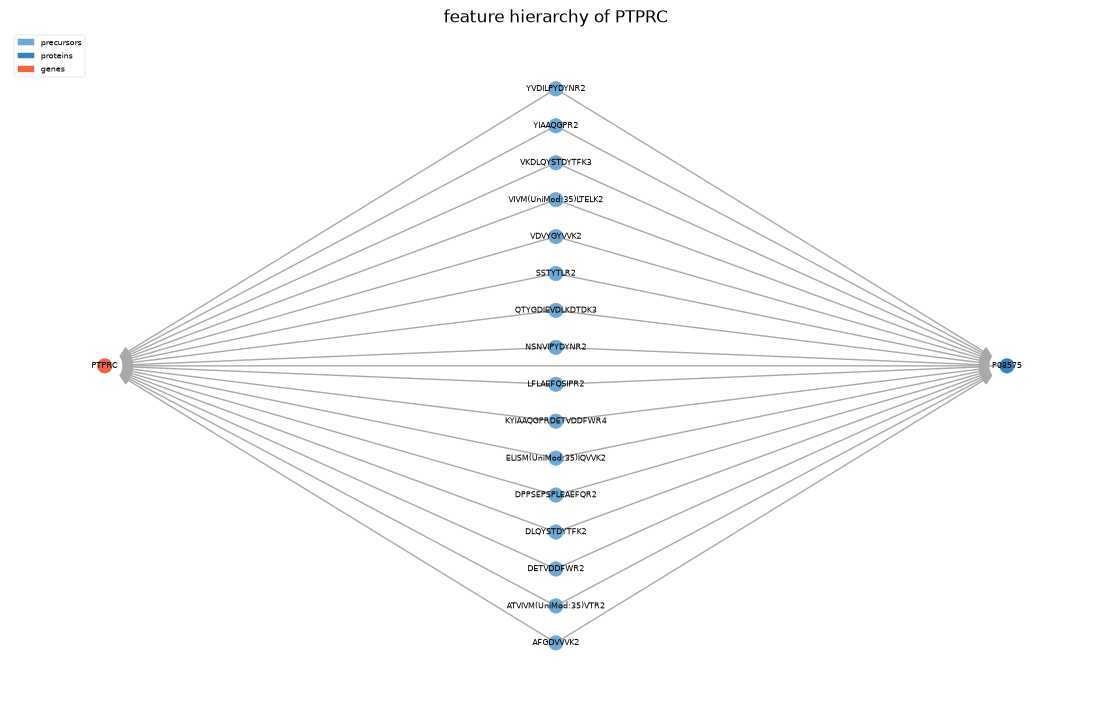

In [36]:
# Colour each node by the level it lives on. Node order follows subgraph.var_names.
level_colors = {
    "precursors": at.pl.BaseColors.get("lightblue"),
    "proteins": at.pl.BaseColors.get("blue"),
    "genes": at.pl.BaseColors.get("orange"),
}
level_of = {name: level for level, mod in subgraph.mod.items() for name in mod.var_names}
node_colors = [level_colors[level_of[name]] for name in subgraph.var_names]

fig, axm = at.pl.create_figure(1, 1, figsize=(11, 7))
ax = axm.next()

subgraph.link.pl.graph(
    ax=ax,
    node_color=node_colors,
    node_size=110,
    with_labels=True,
    font_size=6,
    arrows=True,
    arrowsize=16,
    edge_color="darkgrey",
    min_target_margin=12,  # keep arrowheads clear of the node markers
)
at.pl.add_legend_to_axes_from_patches(
    ax,
    [mpatches.Patch(color=c, label=level) for level, c in level_colors.items()],
    loc="upper left",
)
ax.set_title(f"feature hierarchy of {gene_of_interest}");

One gene, one protein group, and the precursors quantified for it. Every arrow points
from the specific to the general: precursor → protein → gene.

Each precursor also links **directly** to the gene, so "which precursors support this
gene?" is a single query — no need to walk the hierarchy level by level.

## 9. From one protein to its precursors

Now the query we actually came for. `include_mods="precursors"` restricts the result
to the precursor modality, giving us exactly the feature set we want to highlight.

In [37]:
poi_precursors = (
    mdata.link.query.ancestors(PROTEIN_OF_INTEREST, include_mods="precursors")
    .mod["precursors"]
    .var_names
)

# Not every precursor survives the completeness filter from step 4
tested = [p for p in poi_precursors if p in precursors.var_names]

print(f"{gene_of_interest} ({PROTEIN_OF_INTEREST})")
print(f"  precursors in the report:   {len(poi_precursors)}")
print(f"  precursors after filtering: {len(tested)}")
print("  examples:", list(poi_precursors[:4]))

PTPRC (P08575)
  precursors in the report:   16
  precursors after filtering: 13
  examples: ['AFGDVVVK2', 'ATVIVM(UniMod:35)VTR2', 'DETVDDFWR2', 'DLQYSTDYTFK2']


## 10. The precursor volcano, with one protein highlighted

Same test, same plotting function — just run on the ~20,000-precursor matrix instead of
the ~5,000-protein one, with our protein's precursors promoted to their own layer.
Because layers are matched in order and the highlight layer comes first, those points
are drawn on top of everything else.

In [38]:
de_precursors = at.tl.diff_exp_ttest(
    precursors,
    between_column=CONDITION,
    comparison=COMPARISON,
    min_valid_values=3,
)

# Mark the precursors that mulink told us belong to our protein
poi_label = f"{gene_of_interest} precursors"
de_precursors["highlight"] = "other precursors"
de_precursors.loc[de_precursors.index.isin(tested), "highlight"] = poi_label

print(de_precursors["highlight"].value_counts().to_string())

Comparing groups: Cancer vs Immune
highlight
other precursors    20592
PTPRC precursors       13


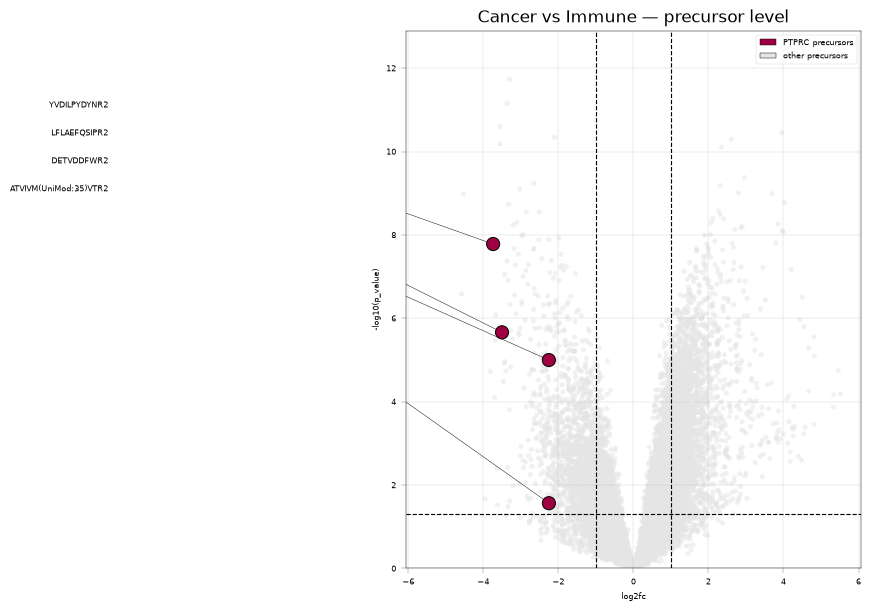

In [39]:
fig, axm = at.pl.create_figure(1, 1, figsize=(8, 6))
ax = axm.next()

at.pl.volcano(
    data=de_precursors,
    x_column="log2fc",
    y_column="-log10(p_value)",
    ax=ax,
    layers=[
        # 4th element of the tuple = extra plotting kwargs for this layer only
        (
            "highlight", poi_label, poi_label,
            {"scatter_kwargs": {"s": 90, "edgecolor": "black", "linewidth": 0.7, "zorder": 5}},
        ),
        (
            "highlight", "other precursors", "other precursors",
            {"scatter_kwargs": {"s": 10, "alpha": 0.5}},
        ),
    ],
    color_dict={
        poi_label: at.pl.BaseColors.get("red"),
        "other precursors": at.pl.BaseColors.get("grey", lighten=0.4),
    },
    label_layers=[poi_label],
    max_labels=8,
    x_label_anchors=[-14],
    x_thresholds=(-FC_CUTOFF, FC_CUTOFF),
    legend="auto",
)
ax.set_title(f"{COMPARISON[0]} vs {COMPARISON[1]} — precursor level");

### Where did the other precursors go?

Count the red points — there are only four, far fewer than the precursors `mulink`
handed us. The accounting goes: **16** precursors linked to CD45 in the report, **13**
surviving the completeness filter, **8** with a fold change, and only **4** with a
p-value. Two guard rails are responsible:

* a fold change needs at least one measurement in *each* group, so the 5 precursors
  never seen in a tumour region have no `log2fc` at all;
* `min_valid_values=3` needs three *measured* samples in each group for a t-test, and
  anything short of that returns `NaN` — which a volcano plot cannot place.

For a protein this strongly restricted to one compartment, that is not a flaw in the
data; it *is* the finding. The table below shows the detection counts behind each
precursor: most of CD45's precursors were seen in 0–2 of the 9 tumour regions and in
all 11 immune regions. **The strongest evidence here is the least testable**, which is
a trade-off worth understanding before you tune these thresholds.

In [40]:
# How many samples per group actually measured each CD45 precursor?
poi_intensities = precursors[:, tested].to_df().join(precursors.obs[CONDITION])
detection = poi_intensities.groupby(CONDITION, observed=True).count().T

group_sizes = precursors.obs[CONDITION].value_counts()
detection.columns = [f"detected in {c} (n={group_sizes[c]})" for c in detection.columns]

detection = detection.join(de_precursors[["log2fc", "p_value", "fdr"]])
detection.sort_values("fdr")

,detected in Cancer (n=9),detected in Immune (n=11),log2fc,p_value,fdr
YVDILPYDYNR2,8,11,-3.741485,1.657430e-08,0.000007
LFLAEFQSIPR2,9,11,-3.504623,2.176974e-06,0.000121
DETVDDFWR2,3,11,-2.256256,1.004749e-05,0.000311
ATVIVM(UniMod:35)VTR2,3,11,-2.254604,2.731588e-02,0.067644
AFGDVVVK2,2,11,-1.906988,NaN,NaN
DLQYSTDYTFK2,1,10,-0.664881,NaN,NaN
ELISM(UniMod:35)IQVVK2,2,10,-1.590123,NaN,NaN
NSNVIPYDYNR2,2,11,-1.906857,NaN,NaN
QTYGDIEVDLKDTDK3,0,11,NaN,NaN,NaN
SSTYTLR2,0,8,NaN,NaN,NaN


In [41]:
poi_stats = de_precursors.loc[de_precursors["highlight"] == poi_label]
testable = poi_stats.dropna(subset=["p_value"])
protein_log2fc = de_proteins.loc[PROTEIN_OF_INTEREST, "log2fc"]

n_agree = int((testable["log2fc"] * protein_log2fc > 0).sum())  # same sign as the protein
n_signif = int((testable["fdr"] < FDR_CUTOFF).sum())

print(f"protein-level log2fc:                    {protein_log2fc:>6.2f}")
print(f"precursors linked / kept / testable:     {len(poi_precursors)} / {len(tested)} / {len(testable)}")
print(f"testable precursor log2fc, median:       {testable['log2fc'].median():>6.2f}")
print(f"testable precursor log2fc, range:        {testable['log2fc'].min():.2f} to {testable['log2fc'].max():.2f}")
print(f"agreeing in sign with the protein:       {n_agree} / {len(testable)}")
print(f"significant on their own (fdr < {FDR_CUTOFF}):   {n_signif} / {len(testable)}")

protein-level log2fc:                     -3.42
precursors linked / kept / testable:     16 / 13 / 4
testable precursor log2fc, median:        -2.88
testable precursor log2fc, range:        -3.74 to -2.25
agreeing in sign with the protein:       4 / 4
significant on their own (fdr < 0.05):   3 / 4


### Was the protein-level number trustworthy?

Yes. All four testable precursors move in the same direction as the protein-level
estimate, each is significant on its own, and the median precursor fold change sits
close to the protein's. The untestable ones point the same way for the strongest
possible reason: they were not detected in tumour regions at all.

A protein whose precursors scattered across both sides of the volcano would be the
warning sign — a shared peptide, a mis-assigned precursor, an interference — and worth
looking at before putting it in a figure.

The two panels below make the same point from the raw numbers: the protein is a clean
on/off difference between compartments, and its precursors are shifted as a coherent
group relative to the 20,000 others.

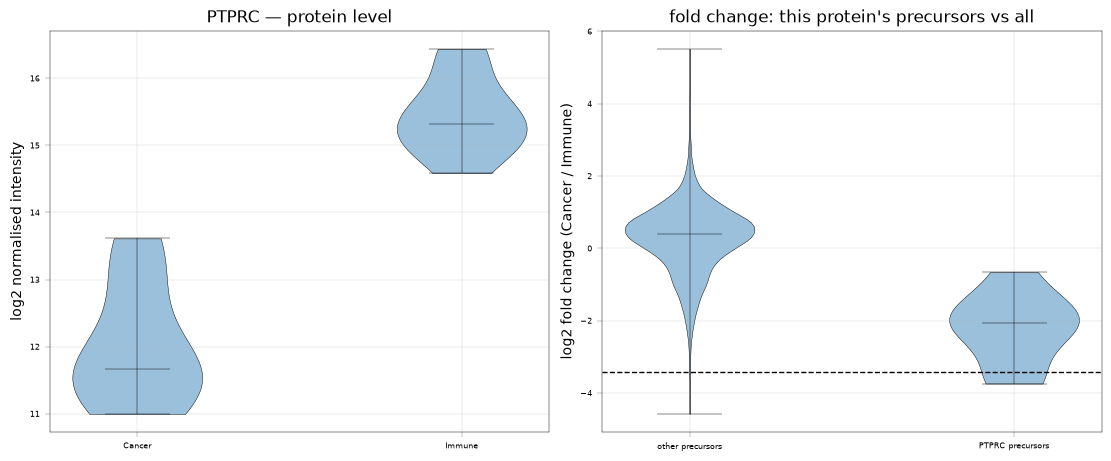

In [42]:
fig, axm = at.pl.create_figure(1, 2, figsize=(11, 4.5))
ax_protein, ax_fc = axm.next(), axm.next()

# (a) the protein itself, per compartment
at.pl.violinplot(
    ax=ax_protein,
    data=adata_filt_70pct,
    grouping_column=CONDITION,
    value_column=PROTEIN_OF_INTEREST,
)
ax_protein.set_ylabel("log2 normalised intensity")
ax_protein.set_title(f"{gene_of_interest} — protein level")

# (b) its precursors' fold changes against the global distribution
fold_changes = de_precursors[["log2fc", "highlight"]].dropna(subset=["log2fc"])
at.pl.violinplot(
    ax=ax_fc,
    data=fold_changes,
    grouping_column="highlight",
    value_column="log2fc",
)
ax_fc.axhline(protein_log2fc, color="black", linestyle="--", linewidth=1)
ax_fc.set_ylabel("log2 fold change (Cancer / Immune)")
ax_fc.set_title("fold change: this protein's precursors vs all");

## Recap

What we did, and which tool did it:

| Step | Call |
| --- | --- |
| One report → three matrices | `at.io.read_psm_table(..., level=..., var_columns=...)` |
| Metadata onto samples | `at.pp.add_metadata(..., axis=0)` |
| normalise → log → filter | `at.pp.normalize`, `at.pp.nanlog`, `at.pp.filter_data_completeness` |
| Is the effect there at all? | `at.pp.impute_gaussian`, `at.tl.pca`, `at.pl.plot_pca` |
| Which proteins change? | `at.tl.diff_exp_ttest`, `at.pl.volcano` |
| Remember how the levels relate | `at.io.mulink_from_anndatas` |
| Protein → its precursors | `mdata.link.query.ancestors(..., include_mods="precursors")` |

The `mulink` step is what made the last question cheap. Once the hierarchy lives in
the object, *"show me the evidence behind this hit"* is a one-line query instead of a
merge you have to get right by hand — and it stays correct as you subset, filter and
pass the object around.

### Things to try next

* Change `PROTEIN_OF_INTEREST` to `"P13796"` (LCP1, more precursors) or `"P00488"`
  (F13A1) and re-run from step 9.
* Swap the comparison to the two donors — `CONDITION = "sample_id"`,
  `COMPARISON = ("991", "992")` — to see how little separates them relative to the
  compartments.
* Use `descendants()` in the other direction: start from a *precursor* and ask which
  protein and gene it supports.
* Loosen `min_valid_values` to `2`, or raise `max_missing_fraction`, and watch how
  many of CD45's precursors become testable.
* For small groups, try the moderated test `at.tl.diff_exp_ebayes` and compare hit
  lists.
* Every function's docstring carries best-practice notes and runnable examples —
  `help(at.tl.diff_exp_ttest)` is genuinely worth reading.